# Sistema y simulación

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from numba import njit

@njit
def time_series(x_0, steps, dt, params):
    tau = params[0]
    K = params[1]
    sigma = params[2]
    x = np.zeros(steps)
    x[0] = x_0[0]
    epsilon = np.random.standard_normal(steps)

    for i in range(1, steps):
        dx_dt = x[i-1] * (1 - x[i-1] / K) / tau + sigma / tau * epsilon[i-1]
        x[i] = x[i-1] + dx_dt * dt

    return x

@njit
def samples(x_0, steps, dt, params):
    tau = params[0]
    K = params[1]
    sigma = params[2]
    N = np.shape(x_0)[0]
    x = np.zeros(N)
    x = x_0

    for i in range(1, steps):
        epsilon = np.random.standard_normal(N)

        dx_dt = x * (1 + sigma * epsilon - x / K) / tau
        x = x + dx_dt * dt

    return x

## Primera ley

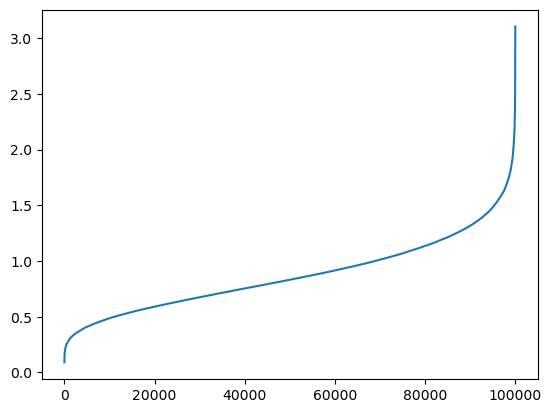

mu:  0.8744905875624264
std:  0.33213853459247644


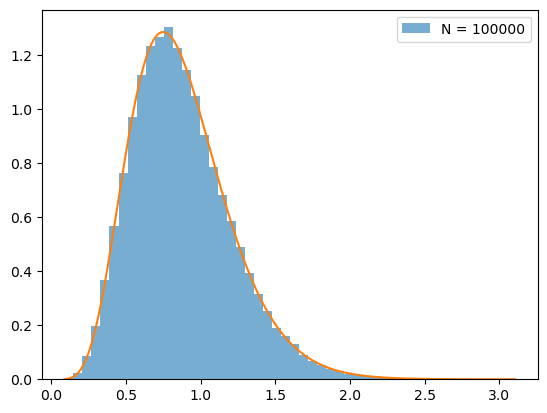

In [11]:
N = 100000
x_0 = np.ones(N)
steps = 5000
dt = 0.01
tau = 4
K = 1
sigma = 1
params = (tau, K, sigma/np.sqrt(dt))
alpha = 2 * tau / sigma**2 - 1
beta = 2 * tau / (K * sigma**2)

x = samples(x_0, steps, dt, params)
plt.plot(np.sort(x))
plt.show()

mu = x.mean()
std = x.std()
print("mu: ", mu)
print("std: ", std)

_, bins, _ = plt.hist(x, bins=50, density=True, alpha=0.6, label=f"N = {N}")

x_range = np.linspace(bins.min(), bins.max(), 1000)

gamma = beta**alpha / sc.special.gamma(alpha) * x_range ** (alpha-1) * np.exp(-x_range * beta)
plt.plot(x_range, gamma)
plt.legend()

plt.show()

## Segunda ley

Ejecutado paso  0
Ejecutado paso  1
Ejecutado paso  2
Ejecutado paso  3
Ejecutado paso  4
Ejecutado paso  5
Ejecutado paso  6
Ejecutado paso  7
Ejecutado paso  8
Ejecutado paso  9
Ejecutado paso  10
Ejecutado paso  11
Ejecutado paso  12
Ejecutado paso  13
Ejecutado paso  14
Ejecutado paso  15
Ejecutado paso  16
Ejecutado paso  17
Ejecutado paso  18
Ejecutado paso  19
Ejecutado paso  20
Ejecutado paso  21
Ejecutado paso  22
Ejecutado paso  23
Ejecutado paso  24
Ejecutado paso  25
Ejecutado paso  26
Ejecutado paso  27
Ejecutado paso  28
Ejecutado paso  29
Ejecutado paso  30
Ejecutado paso  31
Ejecutado paso  32
Ejecutado paso  33
Ejecutado paso  34
Ejecutado paso  35
Ejecutado paso  36
Ejecutado paso  37
Ejecutado paso  38
Ejecutado paso  39
Ejecutado paso  40
Ejecutado paso  41
Ejecutado paso  42
Ejecutado paso  43
Ejecutado paso  44
Ejecutado paso  45
Ejecutado paso  46
Ejecutado paso  47
Ejecutado paso  48
Ejecutado paso  49
Ejecutado paso  50
Ejecutado paso  51
Ejecutado paso  52
Eje

Text(0, 0.5, 'Variance')

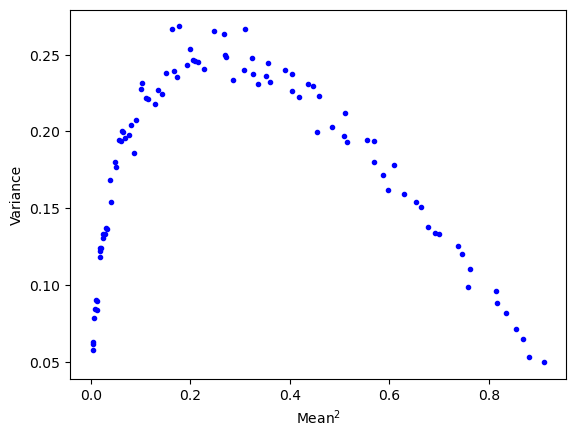

In [6]:
tau_range = 1 / np.linspace(2, 0.1, 100)
K_range = np.linspace(1, 1000, 100)
sigma_range = np.sqrt(np.linspace(0, 3, 100))

N = 5000
x_0 = np.ones(N)
steps = 3000
dt = 0.01
tau = 4
K = 1
sigma = 1

# Variando tau
mean = np.zeros(len(tau_range))
var = np.zeros(len(tau_range))

for i in range(len(tau_range)):
    params = (tau_range[i], K, sigma/np.sqrt(dt))
    rectified_steps = steps*2*tau_range[i]
    x = samples(x_0, rectified_steps, dt, params)
    mean[i] = x.mean()
    var[i] = x.var()
    print("Ejecutado paso ", i)

plt.plot(mean**2, var, 'b.')
plt.xlabel(r"Mean$^2$")
plt.ylabel("Variance")
